TESTE DAS FUNÇÕES DO PLOT_UTILS.PY

1. Carregando dados...
BASE: c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\Precos de Energia BR\Scripts
ROOT: c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\Precos de Energia BR
Dados carregados: 255072 registros
Colunas: ['Hora', 'Submercado', 'Data', 'Preço']
Período: 2018-04-17 00:00:00 até 2025-08-06 00:00:00
Submercados: ['SUDESTE' 'SUL' 'NORDESTE' 'NORTE']

2. Importando funções...
BASE: c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\Precos de Energia BR\Scripts
ROOT: c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\Precos de Energia BR
Funções importadas com sucesso!

3. Testando funções...
Teste 1: plot_price


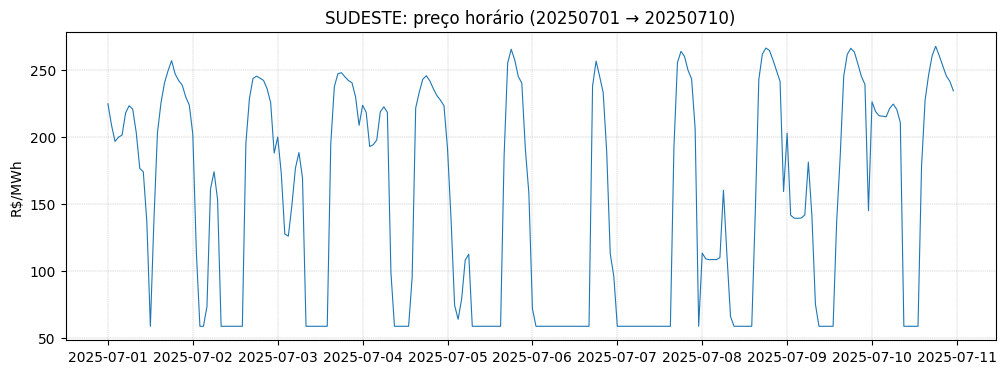

Teste 2: plot_spread


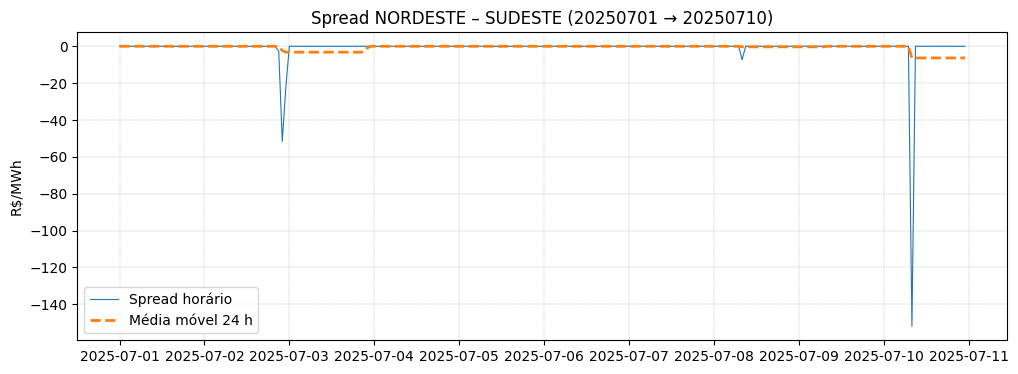

Teste 3: plot_price_daily


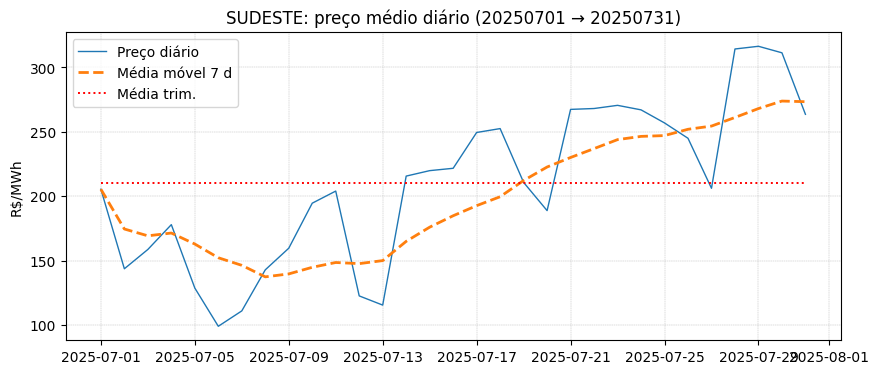

Teste 4: plot_spread_daily


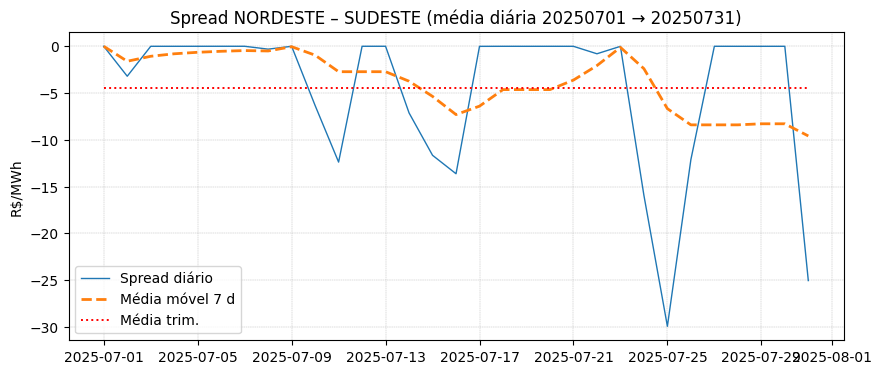


Testes concluídos!


In [4]:
# ===========================================
# TESTE DAS FUNÇÕES DO PLOT_UTILS.PY
# ===========================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# 1. CONFIGURAÇÃO DOS CAMINHOS
def setup_paths():
    """Configura os caminhos do projeto."""
    try:
        # Detectar o diretório atual
        current_dir = Path.cwd()
        
        # Se estamos no diretório Scripts, usar ele
        if current_dir.name == "Scripts":
            BASE = current_dir
            ROOT = BASE.parent
        else:
            # Procurar pelo diretório Scripts
            for parent in current_dir.parents:
                scripts_dir = parent / "Scripts"
                if scripts_dir.exists():
                    BASE = scripts_dir
                    ROOT = BASE.parent
                    break
            else:
                raise FileNotFoundError("Diretório Scripts não encontrado")
        
        print(f"BASE: {BASE}")
        print(f"ROOT: {ROOT}")
        return BASE, ROOT
        
    except Exception as e:
        print(f"Erro ao configurar caminhos: {e}")
        raise

# 2. CARREGAR DADOS
def load_base_master():
    """Carrega a base master."""
    try:
        BASE, ROOT = setup_paths()
        
        # Caminho para o arquivo de dados
        data_path = ROOT / "Data" / "processed" / "pld" / "base_master.parquet"
        
        if not data_path.exists():
            raise FileNotFoundError(f"Arquivo não encontrado: {data_path}")
        
        # Carregar dados
        df = pd.read_parquet(data_path)
        print(f"Dados carregados: {len(df)} registros")
        print(f"Colunas: {df.columns.tolist()}")
        print(f"Período: {df['Data'].min()} até {df['Data'].max()}")
        print(f"Submercados: {df['Submercado'].unique()}")
        
        return df
        
    except Exception as e:
        print(f"Erro ao carregar dados: {e}")
        raise

# 3. IMPORTAR FUNÇÕES DO PLOT_UTILS
def import_plot_functions():
    """Importa as funções do plot_utils.py."""
    try:
        BASE, ROOT = setup_paths()
        
        # Adicionar o diretório Scripts ao path
        if str(BASE) not in sys.path:
            sys.path.insert(0, str(BASE))
        
        # Importar as funções
        from plot_utils import (
            plot_price,
            plot_spread, 
            plot_price_daily,
            plot_spread_daily
        )
        
        print("Funções importadas com sucesso!")
        return plot_price, plot_spread, plot_price_daily, plot_spread_daily
        
    except Exception as e:
        print(f"Erro ao importar funções: {e}")
        raise

# 4. FUNÇÃO PRINCIPAL
def main():
    """Função principal para teste."""
    print("=" * 50)
    print("TESTE DAS FUNÇÕES DO PLOT_UTILS.PY")
    print("=" * 50)
    
    # Carregar dados
    print("\n1. Carregando dados...")
    df = load_base_master()
    
    # Importar funções
    print("\n2. Importando funções...")
    plot_price, plot_spread, plot_price_daily, plot_spread_daily = import_plot_functions()
    
    # Testar funções
    print("\n3. Testando funções...")
    
    # Teste 1: Preço horário
    print("Teste 1: plot_price")
    fig1 = plot_price(df, "SUDESTE", "20250701", "20250710")
    plt.show()
    
    # Teste 2: Spread horário
    print("Teste 2: plot_spread")
    fig2 = plot_spread(df, "NORDESTE", "20250701", "20250710", ma_hours=24)
    plt.show()
    
    # Teste 3: Preço diário
    print("Teste 3: plot_price_daily")
    fig3 = plot_price_daily(df, "SUDESTE", "20250701", "20250731", ma_days=7)
    plt.show()
    
    # Teste 4: Spread diário
    print("Teste 4: plot_spread_daily")
    fig4 = plot_spread_daily(df, "NORDESTE", "20250701", "20250731", ma_days=7)
    plt.show()
    
    print("\nTestes concluídos!")
    return df, plot_price, plot_spread, plot_price_daily, plot_spread_daily

# 5. EXECUTAR SE FOR O ARQUIVO PRINCIPAL
if __name__ == "__main__":
    df, plot_price, plot_spread, plot_price_daily, plot_spread_daily = main()

In [5]:
# ------------------------------------------------------------------
# Helper – recorta intervalo e garante Hora como int
# ------------------------------------------------------------------
def _slice(df, start, end):
    mask = (
        (df["Data"] >= pd.to_datetime(start)) &
        (df["Data"] <= pd.to_datetime(end))
    )
    return df.loc[mask].assign(Hora=lambda d: d["Hora"].astype(int))


In [6]:
df = load_base_master()

BASE: c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\Precos de Energia BR\Scripts
ROOT: c:\Users\joao.barbosa\Desktop\Códigos\Codigos ONS\Precos de Energia BR
Dados carregados: 255072 registros
Colunas: ['Hora', 'Submercado', 'Data', 'Preço']
Período: 2018-04-17 00:00:00 até 2025-08-06 00:00:00
Submercados: ['SUDESTE' 'SUL' 'NORDESTE' 'NORTE']


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_spread_armazenamento_diario(
    df_pld, 
    target_sub, 
    start, 
    end, 
    storage_hours_high=(18, 21), 
    storage_hours_low=(9, 12), 
    spread_ma_days=30
):
    """
    Plota apenas o spread de armazenamento diário (apenas valores positivos, negativos são considerados zero),
    sua média móvel e as médias trimestrais do spread.
    O spread de armazenamento é a diferença entre a média do preço nas horas
    storage_hours_high e a média do preço nas horas storage_hours_low.
    """
    # Filtrar apenas o submercado alvo ANTES de calcular o spread e a média móvel
    d_sub = df_pld[df_pld["Submercado"] == target_sub].copy()

    # Calcular spread de armazenamento diário em TODO o período disponível para o submercado
    d_high = d_sub[(d_sub["Hora"] >= storage_hours_high[0]) & (d_sub["Hora"] <= storage_hours_high[1])]
    d_low = d_sub[(d_sub["Hora"] >= storage_hours_low[0]) & (d_sub["Hora"] <= storage_hours_low[1])]

    mean_high = d_high.groupby("Data")["Preço"].mean()
    mean_low = d_low.groupby("Data")["Preço"].mean()
    storage_spread = mean_high - mean_low
    storage_spread = storage_spread.clip(lower=0)  # Só pode ser positivo, negativo vira zero
    storage_spread.name = "Spread Armazenamento"

    # Calcular média móvel do spread ANTES de filtrar o intervalo de datas
    storage_spread_ma = storage_spread.rolling(spread_ma_days, min_periods=1).mean()

    # Filtrar o spread e sua média móvel para o período de interesse
    mask_spread = (storage_spread.index >= pd.to_datetime(start)) & (storage_spread.index <= pd.to_datetime(end))
    storage_spread_plot = storage_spread.loc[mask_spread]
    storage_spread_ma_plot = storage_spread_ma.loc[mask_spread]

    # Plotar apenas o spread e sua média móvel
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(storage_spread_plot.index, storage_spread_plot, color="tab:orange", lw=1.2, label="Spread armazenamento diário")
    ax.plot(storage_spread_ma_plot.index, storage_spread_ma_plot, color="tab:red", lw=2, ls="--", label=f"Média móvel {spread_ma_days}d do spread")

    # Calcular e plotar médias trimestrais do spread de armazenamento
    # Agrupar por trimestre e calcular a média
    q_means = storage_spread_plot.groupby(storage_spread_plot.index.to_period("Q")).mean()
    for q, mean in q_means.items():
        seg_start = max(q.start_time, storage_spread_plot.index.min())
        seg_end = min(q.end_time, storage_spread_plot.index.max())
        if seg_start > seg_end:
            continue
        ax.hlines(mean, seg_start, seg_end, color="blue", ls=":", lw=1.4, label="Média trimestral" if q == q_means.index[0] else None)

    ax.set_title(f"{target_sub}: spread armazenamento ({start} → {end})")
    ax.set_ylabel("R$/MWh")
    ax.grid(True, ls="--", lw=0.3)

    # Legenda
    ax.legend(loc="upper left")

    return fig


Teste 1: plot_price


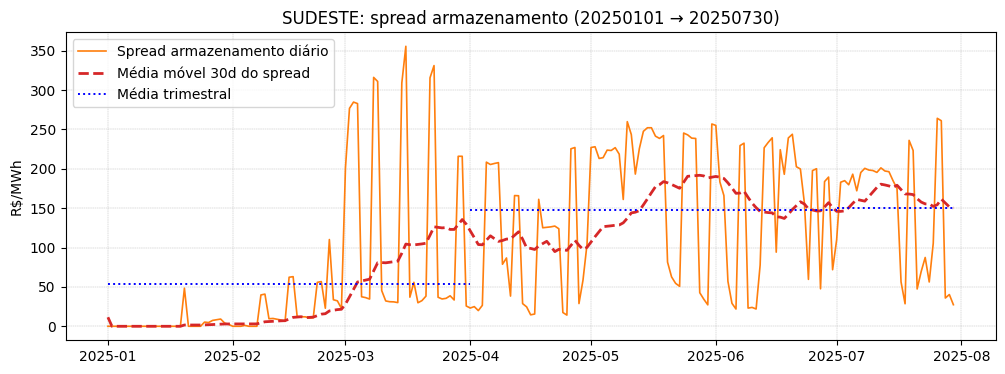

In [8]:
    print("Teste 1: plot_price")
    fig1 = plot_spread_armazenamento_diario(df, "SUDESTE", "20250101", "20250730")
    plt.show()

In [ ]:
# ------------------------------------------------------------------
# Helper: traça médias trimestrais
# ------------------------------------------------------------------
def _draw_quarter_lines(ax, series, start_dt, end_dt, label_base):
    q_means = series.groupby(series.index.to_period("Q")).mean()
    first = True
    for q, mean in q_means.items():
        seg_start = max(q.start_time, start_dt)
        seg_end   = min(q.end_time,   end_dt)
        if seg_start > seg_end:
            continue
        ax.hlines(mean, seg_start, seg_end, color="red", ls=":", lw=1.4,
                  label=f"{label_base}" if first else None)
        first = False

# ------------------------------------------------------------------
# 3.  Preço médio diário
# ------------------------------------------------------------------
def plot_price_daily(df_pld, target_sub, start, end, ma_days=None):
    start_dt, end_dt = pd.to_datetime(start), pd.to_datetime(end)
    d = _slice(df_pld, start_dt, end_dt)
    d = d[d["Submercado"] == target_sub]

    daily = d.groupby("Data", as_index=False)["Preço"].mean().set_index("Data")
    daily.index = pd.to_datetime(daily.index)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(daily.index, daily["Preço"], lw=1, label="Preço diário")

    if ma_days:
        ax.plot(daily.index,
                daily["Preço"].rolling(ma_days, min_periods=1).mean(),
                lw=2, ls="--", label=f"Média móvel {ma_days} d")

    _draw_quarter_lines(ax, daily["Preço"], start_dt, end_dt, "Média trim.")
    ax.set_title(f"{target_sub}: preço médio diário ({start} → {end})")
    ax.set_ylabel("R$/MWh")
    ax.legend(); ax.grid(True, ls="--", lw=0.3)
    return fig